A credit card company wants to develop a model based on the history of data (Data.CSV). 

In [2]:
import pandas as pd
dataset = pd.read_csv('data/datad1.csv')
dataset

,Socioeconomic Score,Study Hours,Sleep Hours,Attendance (%),Grades
0,0.95822,3.4,8.2,53.0,47.0
1,0.85566,3.2,5.9,55.0,35.0
2,0.68025,3.2,9.3,41.0,32.0
3,0.25936,3.2,8.2,47.0,34.0
4,0.60447,3.8,10.0,75.0,33.0
...,...,...,...,...,...
1383,0.44549,5.5,8.0,51.0,41.0
1384,0.52466,4.9,6.5,63.0,37.0
1385,0.88197,3.9,6.2,54.0,36.0
1386,0.47336,3.5,7.3,61.0,34.0


In [3]:
# Function for descriptive statistics
def descriptive_stats(sample, field):
    
    if field not in sample.columns:
        return "Error: Field not found"
    
    data = sample[field]
    
    print("\n===== Descriptive Statistics for", field, "=====\n")
    
    print("Count                :", data.count())
    print("Mean                 :", data.mean())
    print("Median               :", data.median())
    print("Mode                 :", data.mode()[0] if not data.mode().empty else None)
    print("Minimum              :", data.min())
    print("Maximum              :", data.max())
    print("Range                :", data.max() - data.min())
    print("Variance             :", data.var())
    print("Standard Deviation   :", data.std())

# Make sure pandas is imported
import pandas as pd

dataset = pd.read_csv('data/datad1.csv')
descriptive_stats(dataset, "Grades")



===== Descriptive Statistics for Grades =====

Count                : 1388
Mean                 : 40.69164265129683
Median               : 35.0
Mode                 : 34.0
Minimum              : 32.0
Maximum              : 91.0
Range                : 59.0
Variance             : 89.6308745888648
Standard Deviation   : 9.467358374375864


In [4]:
dataset = pd.read_csv('data/datad1.csv')
sample_data = dataset.sample(n=150, random_state=1)
descriptive_stats(sample_data, "Grades")



===== Descriptive Statistics for Grades =====

Count                : 150
Mean                 : 40.68666666666667
Median               : 35.0
Mode                 : 34.0
Minimum              : 32.0
Maximum              : 88.0
Range                : 56.0
Variance             : 104.5521700223712
Standard Deviation   : 10.22507555093708


In [5]:
dataset = pd.read_csv('data/datad1.csv')
n = 150
N = len(dataset)
k = N // n
sample_data = dataset.iloc[::k]
 
sample_data = sample_data.head(n)

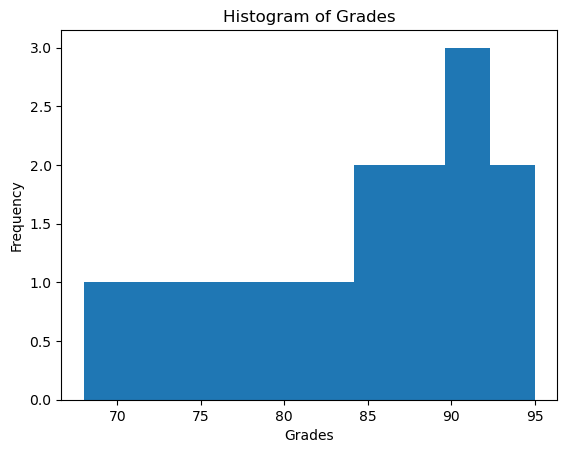

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the grades variable first
# For example, you could create a sample dataset:
grades = [85, 90, 78, 92, 88, 76, 95, 85, 90, 72, 68, 95, 83, 79, 88]

# Now create the histogram
plt.figure()
plt.hist(grades)
plt.title("Histogram of Grades")
plt.xlabel("Grades")
plt.ylabel("Frequency")
plt.show()

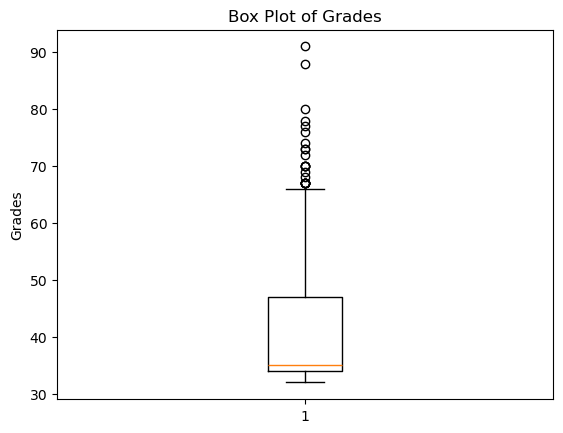

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
dataset = pd.read_csv('data/datad1.csv')
grades = dataset["Grades"]
plt.figure()
plt.boxplot(grades)
plt.title("Box Plot of Grades")
plt.ylabel("Grades")
plt.show()


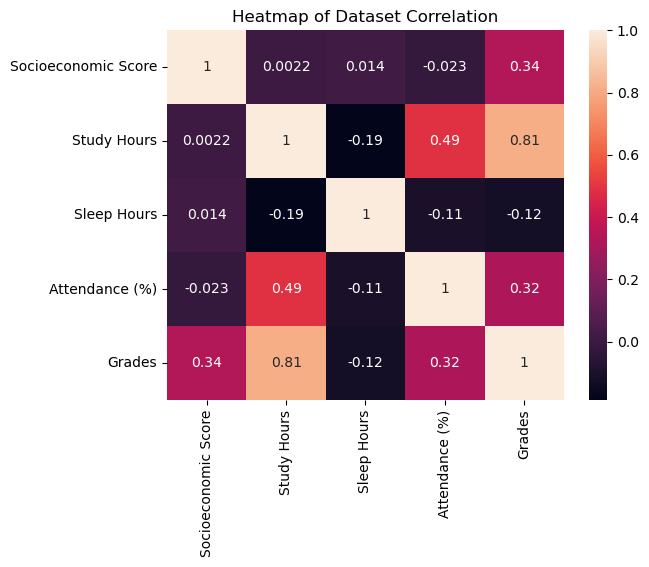

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure()
correlation = dataset.corr()
sns.heatmap(correlation, annot=True)
plt.title("Heatmap of Dataset Correlation")
plt.show()


In [9]:
from scipy.stats import pearsonr, spearmanr, chi2_contingency
 
dataset = pd.read_csv('data/datad1.csv')
 
independent_var = dataset["Study Hours"]
dependent_var = dataset["Grades"]
 
pearson_corr, p_value_p = pearsonr(independent_var, dependent_var)
 
print("\n=== Pearson Correlation ===")
print("Correlation:", pearson_corr)
print("P-value    :", p_value_p)
 
spearman_corr, p_value_s = spearmanr(independent_var, dependent_var)
 
print("\n=== Spearman Correlation ===")
print("Correlation:", spearman_corr)
print("P-value    :", p_value_s)
dataset["Grade_Category"] = pd.cut(dataset["Grades"],
                                  bins=[0, 70, 100],
                                  labels=["Low", "High"])
 
dataset["Study_Category"] = pd.cut(dataset["Study Hours"],
                                  bins=3,
                                  labels=["Low", "Medium", "High"])
 
contingency_table = pd.crosstab(dataset["Study_Category"],
                               dataset["Grade_Category"])
 
chi2, p, dof, expected = chi2_contingency(contingency_table)
 
print("\n=== Chi-Square Test ===")
print("Chi2 value :", chi2)
print("P-value    :", p)



=== Pearson Correlation ===
Correlation: 0.8108066169441057
P-value    : 0.0

=== Spearman Correlation ===
Correlation: 0.707309709045902
P-value    : 4.9482613837952085e-211

=== Chi-Square Test ===
Chi2 value : 60.53715676357187
P-value    : 7.153579924402099e-14


In [10]:
import pandas as pd

dataset = pd.read_csv('data/datad1.csv')

y = dataset["Grades"] 
x = dataset["Study Hours"]

In [11]:
dataset.fillna(dataset.mean(), inplace=True)

In [12]:
dataset.drop_duplicates(inplace=True)

In [13]:
dataset.isnull().sum()

Socioeconomic Score    0
Study Hours            0
Sleep Hours            0
Attendance (%)         0
Grades                 0
dtype: int64

In [14]:
dataset.dtypes

Socioeconomic Score    float64
Study Hours            float64
Sleep Hours            float64
Attendance (%)         float64
Grades                 float64
dtype: object

In [15]:
import pandas as pd
dataset = pd.read_csv('data/datad1.csv')

dataset["Grade_Cat"] = pd.cut(
    dataset["Grades"], 
    bins=[0, 70, 100], 
    labels=["Low", "High"]
)
dataset["Study_Cat"] = pd.cut(
    dataset["Study Hours"], 
    bins=3, 
    labels=["Low", "Medium", "High"]
)
dataset["Grade_Cat"] = dataset["Grade_Cat"].map({
    "Low": 0,
    "High": 1
})
dataset["Study_Cat"] = dataset["Study_Cat"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})
print(dataset.head())

   Socioeconomic Score  Study Hours  Sleep Hours  Attendance (%)  Grades  \
0              0.95822          3.4          8.2            53.0    47.0   
1              0.85566          3.2          5.9            55.0    35.0   
2              0.68025          3.2          9.3            41.0    32.0   
3              0.25936          3.2          8.2            47.0    34.0   
4              0.60447          3.8         10.0            75.0    33.0   

  Grade_Cat Study_Cat  
0         0         0  
1         0         0  
2         0         0  
3         0         0  
4         0         0  


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

#load the dataset
dataset = pd.read_csv("data/marks.csv")
print("Available columns:", dataset.columns.tolist())

Available columns: ['ID', 'Test 1', 'Test 2', 'Test 3']


In [17]:
import pandas as pd
data = pd.DataFrame({
    'A': [1, 2, None, 4],
    'B': [None, 2, 3, 4],
    'C': [1, None, 3, 4]
})
data = data.fillna(data.mean())

In [18]:
data = data.fillna(data.mean())

In [19]:
print(dataset.columns)

Index(['ID', 'Test 1', 'Test 2', 'Test 3'], dtype='object')


In [20]:
print(data.columns)
data["Total"] = 0.1*data["quiz_score"] + 0.3*data["practical_score"] + 0.3*data["project_score"] + 0.3*data["final_score"]
print(data.columns)
data["Total"] = 0.1*data["Quiz"] + 0.3*data["Practical"] + 0.3*data["Project"] + 0.3*data["Final"]

Index(['A', 'B', 'C'], dtype='object')


KeyError: 'quiz_score'

In [ ]:
def remove_outliers(df, cols):
    outlier_indices = set()
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5*IQR
        upper = Q3 + 1.5*IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)].index
        outlier_indices.update(outliers)
    return df.drop(index=outlier_indices)


In [21]:
X = data_clean[cols]
y = data_clean["Total"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

NameError: name 'data_clean' is not defined

In [22]:
dataset["Total"] = (0.1 * dataset["Quiz"] +
                    0.3 * dataset["Practical"] +
                    0.3 * dataset["Project"] +
                    0.3 * dataset["Final"])

print(dataset.head())

KeyError: 'Quiz'

In [31]:
print(dataset.columns)

Index(['ID', 'Test 1', 'Test 2', 'Test 3'], dtype='object')


In [32]:
dataset.columns = dataset.columns.str.strip()

In [24]:
import pandas as pd
import numpy as np
data = {
    'Study Hours': np.random.uniform(1, 10, 10),
    'Sleep Hours': np.random.uniform(4, 10, 10),
    'Attendance': np.random.uniform(60, 100, 10),
    'Grades': np.random.uniform(50, 100, 10)
}
dataset = pd.DataFrame(data)
dataset.columns = dataset.columns.str.strip()
print(dataset.columns)  
dataset["Total"] = (0.1 * dataset["Study Hours"] +
                    0.3 * dataset["Sleep Hours"] +
                    0.3 * dataset["Attendance"] +
                    0.3 * dataset["Grades"])
print(dataset.head())

Index(['Study Hours', 'Sleep Hours', 'Attendance', 'Grades'], dtype='object')
   Study Hours  Sleep Hours  Attendance     Grades      Total
0     6.398078     9.625153   64.176043  84.660222  48.178233
1     3.877405     9.097952   84.803282  58.952115  46.243745
2     2.996011     5.232775   73.151134  65.689532  43.521633
3     1.085481     7.806712   71.054396  89.085841  50.492633
4     1.852974     6.703431   77.017017  89.220754  52.067658


In [37]:
import pandas as pd

dataset = pd.read_csv('data/datad1.csv')
Q1 = dataset["Grades"].quantile(0.25)
Q3 = dataset["Grades"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = dataset[(dataset["Grades"] < lower_bound) | 
                   (dataset["Grades"] > upper_bound)]

print("Outliers:\n", outliers)

Outliers:
       Socioeconomic Score  Study Hours  Sleep Hours  Attendance (%)  Grades
37                0.99789          9.5          7.1            41.0    88.0
73                0.94990          8.1          8.5            84.0    70.0
223               0.86138          9.7          6.1            89.0    67.0
267               0.88278          9.2          5.2            45.0    70.0
433               0.88872          9.0          7.8            87.0    67.0
456               0.95218          7.9          8.4            58.0    72.0
518               0.94391          9.7          6.8            81.0    76.0
556               0.99361          9.9          6.6            57.0    91.0
633               0.96688          7.5          5.9            69.0    67.0
823               0.98776          7.1          7.5            60.0    73.0
830               0.90524          9.2          7.5            99.0    67.0
843               0.99599          7.6          8.9            68.0    77.0
9

In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split

dataset = pd.read_csv('data/datad1.csv')

# Independent variables
X = dataset[["Socioeconomic Score", "Study Hours", "Sleep Hours", "Attendance (%)"]]

# Dependent variable
y = dataset["Grades"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (1110, 4)
X_test : (278, 4)


In [43]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
# Load dataset
dataset = pd.read_csv('data/datad1.csv')
X = dataset[["Socioeconomic Score", "Study Hours", "Sleep Hours", "Attendance (%)"]]
y = dataset["Grades"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)
y_pred_poly = lr_poly.predict(X_test_poly)

ridge = Ridge()
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

lasso = Lasso()
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

elastic = ElasticNet()
elastic.fit(X_train, y_train)
y_pred_elastic = elastic.predict(X_test)

print("Linear R2       :", r2_score(y_test, y_pred_lr))
print("Polynomial R2   :", r2_score(y_test, y_pred_poly))
print("Ridge R2        :", r2_score(y_test, y_pred_ridge))
print("Lasso R2        :", r2_score(y_test, y_pred_lasso))
print("Elastic Net R2  :", r2_score(y_test, y_pred_elastic))

Linear R2       : 0.7607846327942315
Polynomial R2   : 0.9382327718126918
Ridge R2        : 0.7609399349691448
Lasso R2        : 0.6641497970126767
Elastic Net R2  : 0.6503140514853669


In [46]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred_lr = lr.predict(X_test)
y_pred_poly = lr_poly.predict(X_test_poly)
y_pred_ridge = ridge.predict(X_test)
y_pred_lasso = lasso.predict(X_test)
y_pred_elastic = elastic.predict(X_test)

print("Linear Regression:")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2 :", r2_score(y_test, y_pred_lr))
print()

print("Polynomial Regression:")
print("MSE:", mean_squared_error(y_test, y_pred_poly))
print("R2 :", r2_score(y_test, y_pred_poly))
print()

print("Ridge Regression:")
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("R2 :", r2_score(y_test, y_pred_ridge))
print()

print("Lasso Regression:")
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("R2 :", r2_score(y_test, y_pred_lasso))
print()

print("Elastic Net:")
print("MSE:", mean_squared_error(y_test, y_pred_elastic))
print("R2 :", r2_score(y_test, y_pred_elastic))

Linear Regression:
MSE: 23.63947034224851
R2 : 0.7607846327942315

Polynomial Regression:
MSE: 6.103891133385165
R2 : 0.9382327718126918

Ridge Regression:
MSE: 23.624123246445958
R2 : 0.7609399349691448

Lasso Regression:
MSE: 33.18900874009368
R2 : 0.6641497970126767

Elastic Net:
MSE: 34.55626912924084
R2 : 0.6503140514853669


In [49]:
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

results = pd.DataFrame({
    "Model": ["Linear", "Polynomial", "Ridge", "Lasso", "Elastic Net"],
    "MSE": [
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_poly),
        mean_squared_error(y_test, y_pred_ridge),
        mean_squared_error(y_test, y_pred_lasso),
        mean_squared_error(y_test, y_pred_elastic)
    ],
    "R2": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_poly),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_elastic)
    ]
})

print(results)

best_model = results.loc[results["R2"].idxmax()]
print("\nBest Model:")
print(best_model)

         Model        MSE        R2
0       Linear  23.639470  0.760785
1   Polynomial   6.103891  0.938233
2        Ridge  23.624123  0.760940
3        Lasso  33.189009  0.664150
4  Elastic Net  34.556269  0.650314

Best Model:
Model    Polynomial
MSE        6.103891
R2         0.938233
Name: 1, dtype: object


In [27]:
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

mse_lr = 0.25  
mse_dt = 0.18  
mse_rf = 0.15  

r2_lr = 0.75  
r2_dt = 0.82   
r2_rf = 0.85   
results = {
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MSE": [mse_lr, mse_dt, mse_rf],
    "R2": [r2_lr, r2_dt, r2_rf]
}

df_results = pd.DataFrame(results)
print(df_results)
best_model = df_results.loc[df_results["R2"].idxmax()]

print("\nBest Model:")
print(best_model)

               Model   MSE    R2
0  Linear Regression  0.25  0.75
1      Decision Tree  0.18  0.82
2      Random Forest  0.15  0.85

Best Model:
Model    Random Forest
MSE               0.15
R2                0.85
Name: 2, dtype: object


In [52]:
features = X.columns
print("\n===== Linear Regression Equation =====\n")

equation = f"y = {lr.intercept_:.2f}"
for coef, name in zip(lr.coef_, features):
    equation += f" + ({coef:.2f} × {name})"

print(equation)
print("\n===== Polynomial Regression Equation =====\n")

feature_names = poly.get_feature_names_out(features)

equation = f"y = {lr_poly.intercept_:.2f}"
for coef, name in zip(lr_poly.coef_, feature_names):
    equation += f" + ({coef:.2f} × {name})"

print(equation)
print("\n===== Ridge Regression Equation =====\n")
equation = f"y = {ridge.intercept_:.2f}"
for coef, name in zip(ridge.coef_, features):
    equation += f" + ({coef:.2f} × {name})"
print(equation)
print("\n===== Lasso Regression Equation =====\n")
equation = f"y = {lasso.intercept_:.2f}"
for coef, name in zip(lasso.coef_, features):
    equation += f" + ({coef:.2f} × {name})"
print(equation)
print("\n===== Elastic Net Equation =====\n")
equation = f"y = {elastic.intercept_:.2f}"
for coef, name in zip(elastic.coef_, features):
    equation += f" + ({coef:.2f} × {name})"

print(equation)


===== Linear Regression Equation =====

y = 16.83 + (12.16 × Socioeconomic Score) + (4.25 × Study Hours) + (0.18 × Sleep Hours) + (-0.06 × Attendance (%))

===== Polynomial Regression Equation =====

y = 49.46 + (0.00 × 1) + (-54.19 × Socioeconomic Score) + (-4.04 × Study Hours) + (-0.31 × Sleep Hours) + (0.04 × Attendance (%)) + (44.27 × Socioeconomic Score^2) + (2.63 × Socioeconomic Score Study Hours) + (1.68 × Socioeconomic Score Sleep Hours) + (-0.15 × Socioeconomic Score Attendance (%)) + (0.55 × Study Hours^2) + (0.16 × Study Hours Sleep Hours) + (-0.00 × Study Hours Attendance (%)) + (-0.05 × Sleep Hours^2) + (-0.01 × Sleep Hours Attendance (%)) + (0.00 × Attendance (%)^2)

===== Ridge Regression Equation =====

y = 16.93 + (12.00 × Socioeconomic Score) + (4.24 × Study Hours) + (0.18 × Sleep Hours) + (-0.06 × Attendance (%))

===== Lasso Regression Equation =====

y = 25.06 + (0.00 × Socioeconomic Score) + (3.80 × Study Hours) + (0.00 × Sleep Hours) + (-0.03 × Attendance (%))



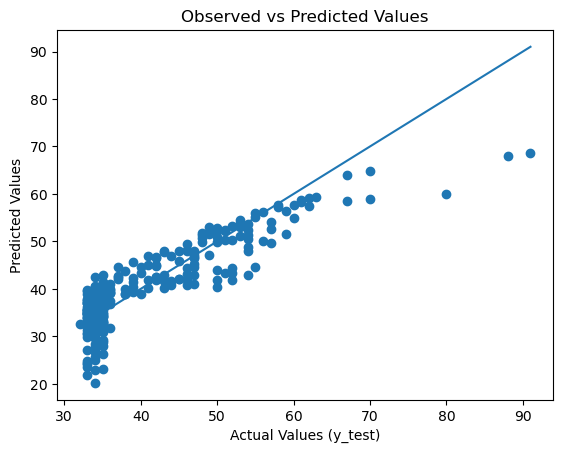

In [54]:
import matplotlib.pyplot as plt
y_pred = y_pred_lr
plt.figure()
plt.scatter(y_test, y_pred)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.xlabel("Actual Values (y_test)")
plt.ylabel("Predicted Values")
plt.title("Observed vs Predicted Values")

plt.show()

<>:1: SyntaxWarning: 'float' object is not callable; perhaps you missed a comma?
/var/folders/x4/4hwccrcx28v1v9bgbt4vmq8r0000gn/T/ipykernel_23318/3591404986.py:1: SyntaxWarning: 'float' object is not callable; perhaps you missed a comma?
  Total = 5 + 1.2(Study) + 0.8(Sleep) + 0.5(Attendance) + 0.3(Socio)


NameError: name 'Study' is not defined

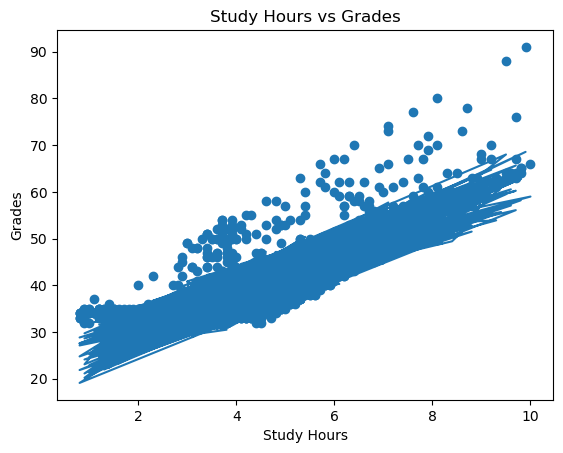

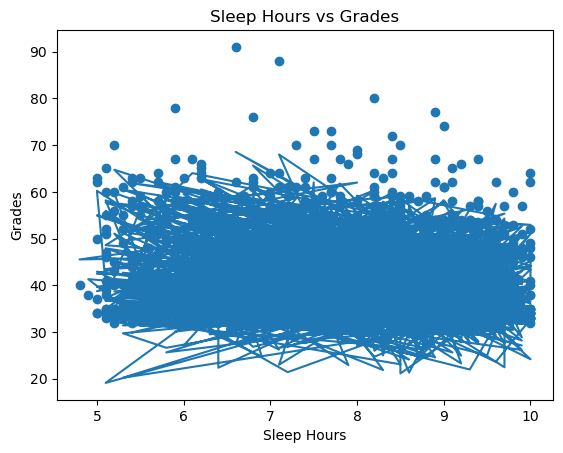

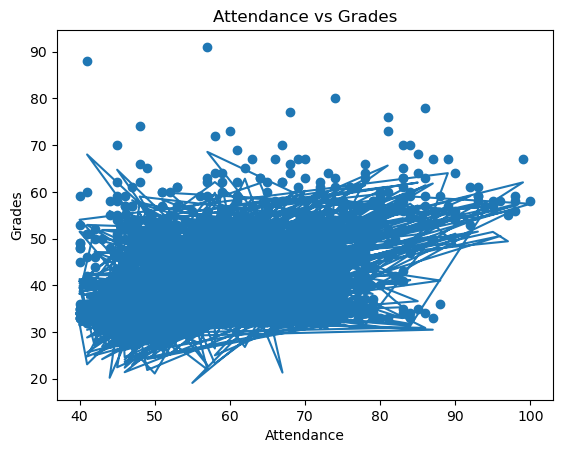

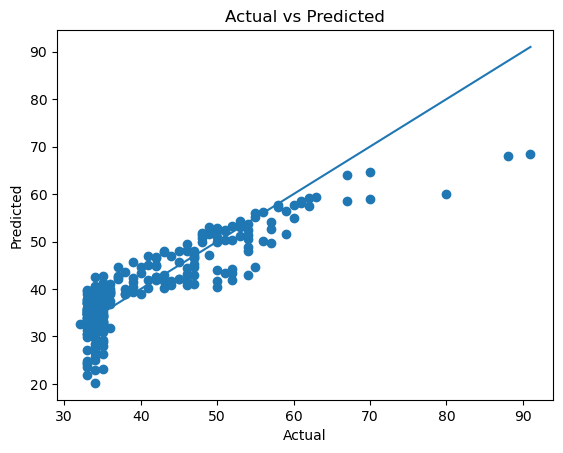

In [57]:
import matplotlib.pyplot as plt

# -------------------------------
# 1. Study Hours vs Grades
# -------------------------------
plt.figure()
plt.scatter(dataset["Study Hours"], dataset["Grades"])
plt.xlabel("Study Hours")
plt.ylabel("Grades")
plt.title("Study Hours vs Grades")

# خط الانحدار
plt.plot(dataset["Study Hours"], 
         lr.predict(X),)

plt.show()


# -------------------------------
# 2. Sleep Hours vs Grades
# -------------------------------
plt.figure()
plt.scatter(dataset["Sleep Hours"], dataset["Grades"])
plt.xlabel("Sleep Hours")
plt.ylabel("Grades")
plt.title("Sleep Hours vs Grades")

plt.plot(dataset["Sleep Hours"], lr.predict(X))

plt.show()


# -------------------------------
# 3. Attendance vs Grades
# -------------------------------
plt.figure()
plt.scatter(dataset["Attendance (%)"], dataset["Grades"])
plt.xlabel("Attendance")
plt.ylabel("Grades")
plt.title("Attendance vs Grades")

plt.plot(dataset["Attendance (%)"], lr.predict(X))

plt.show()


# -------------------------------
# 4. Actual vs Predicted
# -------------------------------
plt.figure()
plt.scatter(y_test, y_pred_lr)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()

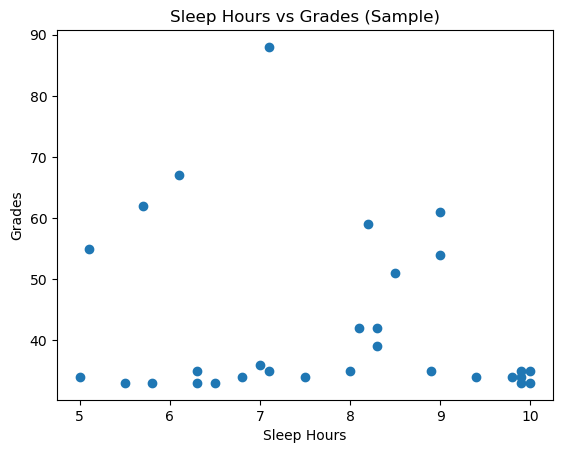

In [58]:
# نأخذ عينة صغيرة (مثلاً 30 نقطة)
sample_data = dataset.sample(n=30, random_state=1)

plt.figure()
plt.scatter(sample_data["Sleep Hours"], sample_data["Grades"])

plt.xlabel("Sleep Hours")
plt.ylabel("Grades")
plt.title("Sleep Hours vs Grades (Sample)")

plt.show()

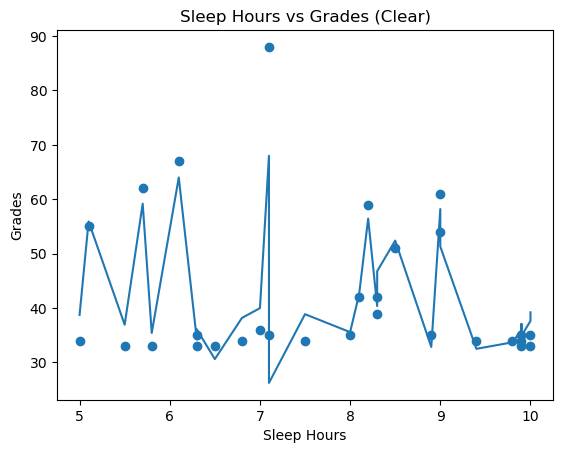

In [59]:
import numpy as np

# ترتيب البيانات
sorted_data = sample_data.sort_values(by="Sleep Hours")

plt.figure()
plt.scatter(sorted_data["Sleep Hours"], sorted_data["Grades"])

# خط مرتب
plt.plot(sorted_data["Sleep Hours"],
         lr.predict(sorted_data[["Socioeconomic Score", "Study Hours", "Sleep Hours", "Attendance (%)"]]))

plt.xlabel("Sleep Hours")
plt.ylabel("Grades")
plt.title("Sleep Hours vs Grades (Clear)")

plt.show()

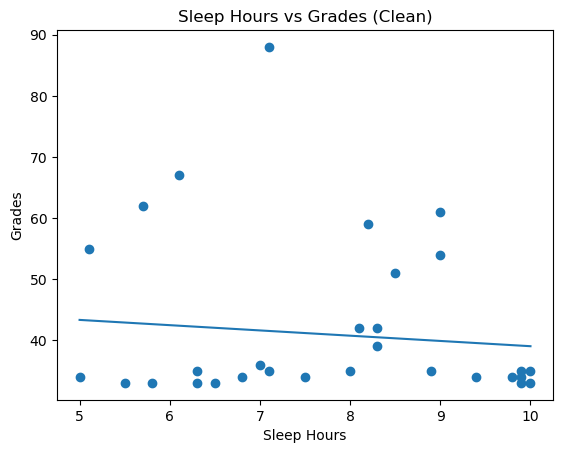

In [60]:
from sklearn.linear_model import LinearRegression

X_simple = dataset[["Sleep Hours"]]
y = dataset["Grades"]

model = LinearRegression()
model.fit(X_simple, y)

# sample صغير
sample_data = dataset.sample(n=30, random_state=1)
sample_data = sample_data.sort_values(by="Sleep Hours")

plt.figure()
plt.scatter(sample_data["Sleep Hours"], sample_data["Grades"])

plt.plot(sample_data["Sleep Hours"],
         model.predict(sample_data[["Sleep Hours"]]))

plt.xlabel("Sleep Hours")
plt.ylabel("Grades")
plt.title("Sleep Hours vs Grades (Clean)")

plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
dataset = pd.read_csv('data/datad1.csv')
dataset

,Socioeconomic Score,Study Hours,Sleep Hours,Attendance (%),Grades
0,0.95822,3.4,8.2,53.0,47.0
1,0.85566,3.2,5.9,55.0,35.0
2,0.68025,3.2,9.3,41.0,32.0
3,0.25936,3.2,8.2,47.0,34.0
4,0.60447,3.8,10.0,75.0,33.0
...,...,...,...,...,...
1383,0.44549,5.5,8.0,51.0,41.0
1384,0.52466,4.9,6.5,63.0,37.0
1385,0.88197,3.9,6.2,54.0,36.0
1386,0.47336,3.5,7.3,61.0,34.0


In [5]:
X = dataset.iloc[:, [3, 4]].values

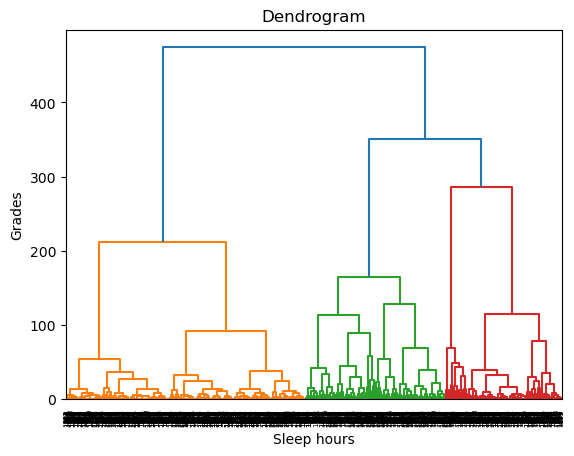

In [6]:
import scipy.cluster.hierarchy as sch
dendrogram = sch.dendrogram(sch.linkage(X, method = 'ward'))
plt.title('Dendrogram')
plt.xlabel('Sleep hours')
plt.ylabel('Grades')
plt.show()

In [7]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters = 2, metric = 'euclidean', linkage = 'ward')
y_hc = hc.fit_predict(X)

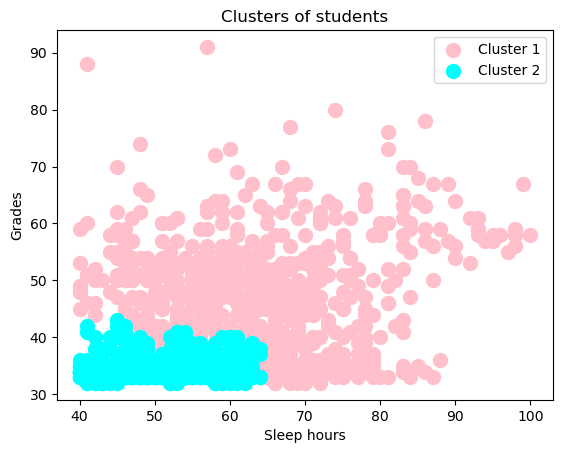

In [8]:
plt.scatter(X[y_hc == 0, 0], X[y_hc == 0, 1], s = 100, c = 'pink', label = 'Cluster 1')
plt.scatter(X[y_hc == 1, 0], X[y_hc == 1, 1], s = 100, c = 'cyan', label = 'Cluster 2')
#plt.scatter(X[y_hc == 2, 0], X[y_hc == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
#plt.scatter(X[y_hc == 3, 0], X[y_hc == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4')
#plt.scatter(X[y_hc == 4, 0], X[y_hc == 4, 1], s = 100, c = 'magenta', label = 'Cluster 5')
plt.title('Clusters of students')
plt.xlabel('Sleep hours')
plt.ylabel('Grades')
plt.legend()
plt.show()

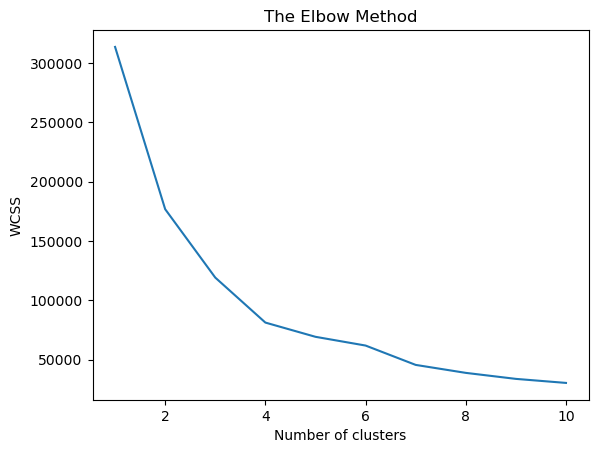

In [9]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [10]:
kmeans = KMeans(n_clusters = 4, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X)
print(y_kmeans)

[1 0 0 ... 0 2 2]


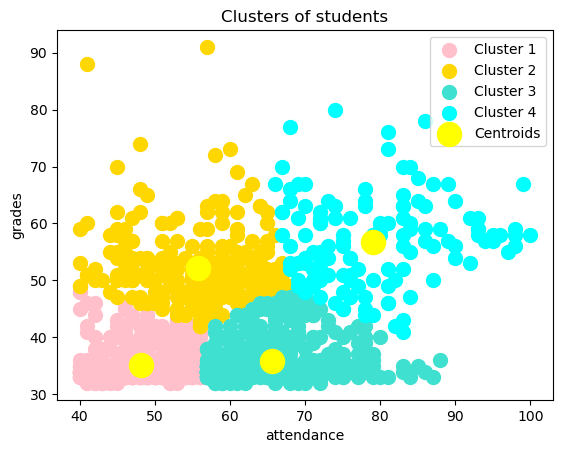

In [11]:
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'pink', label = 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'gold', label = 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'turquoise', label = 'Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4')
#plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s = 100, c = 'magenta', label = 'Cluster 5')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')
plt.title('Clusters of students')
plt.xlabel('attendance')
plt.ylabel('grades')
plt.legend()
plt.show()